
# Correlation Code
-----

In [1]:
from pathlib import Path
import re
import pandas as pd
import numpy as np

# Chapter 6: correlate clustered thermal events with processed news tables.
#
# Workflow:
# 1. Load all FIRMS clustered event files from FIRMS/data/processed/clstrd_*.csv.
# 2. Load all combined news tables from News/data/processed/*_all.csv.
# 3. For each thermal event, find news inside a 24 hour window.
# 4. Pick the nearest news item first, then score it by content and area overlap.
# 5. Keep every thermal event in the output, even if no news match exists.
# 6. Save the results back to FIRMS/data/processed/ as crrltd_*.csv.

ROOT = Path(r"c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubRepository\CE49X\Final Project")
FIRMS_PROCESSED = ROOT / "FIRMS" / "data" / "processed"
NEWS_PROCESSED = ROOT / "News" / "data" / "processed"
MAX_TIME_WINDOW_HOURS = 24
MIN_ACTION_HITS = 2
MIN_CONFLICT_HITS = 4

ACTION_IMPACT_TERMS = [
    "attack",
    "attacked",
    "attacks",
    "strike",
    "struck",
    "strikes",
    "striked",
    "explosion",
    "exploded",
    "explodes",
    "explode",
    "blast",
    "blasted",
    "bomb",
    "bombed",
    "bombing",
    "killed",
    "killing",
    "injured",
    "injury",
    "hit",
    "hits",
    "shelling",
    "bombardment",
    "burning",
    "burned",
    "fire",
]

CONFLICT_TERMS = [
    "war",
    "missile",
    "missiles",
    "rocket",
    "rockets",
    "drone",
    "drones",
    "artillery",
    "invasion",
    "airstrike",
    "airstrikes",
    "raid",
    "raids",
    "frontline",
    "combat",
    "conflict",
    "ukraine",
    "ukrainian",
    "russia",
    "russian",
    "kyiv",
    "kiev",
    "kharkiv",
    "odesa",
    "odessa",
    "crimea",
    "donbas",
    "black sea",
    "zaporizhzhia",
    "energy grid",
    "critical infrastructure",
]

FIRE_TERMS = [
    "wildfire",
    "forest fire",
    "forestfire",
    "fire",
    "brush fire",
    "bushfire",
    "blaze",
    "inferno",
    "arson",
    "flames",
    "burning",
    "smoke",
    "spread",
    "spreaded",
    "wind",
    "burn",
    "burned",
]

pd.set_option("display.max_colwidth", 120)

EXTRA_COLUMNS = [
    "matched_news_count",
    "nearest_delta_time_hours",
    "time_score",
    "action_impact_score",
    "conflict_word_score",
    "fire_word_score",
    "area_score",
    "keyword_hit_count",
    "high_confidence_match",
    "total_score",
    "nearest_news_source",
    "nearest_news_title",
]


def normalize_text(value):
    if pd.isna(value):
        return ""
    text = str(value).lower()
    text = text.replace("'", " ")
    text = re.sub(r"[^a-z0-9\s]+", " ", text)
    text = re.sub(r"\s+", " ", text).strip()
    return text


def unique_hits(text, terms):
    normalized = normalize_text(text)
    hits = []
    for term in terms:
        normalized_term = normalize_text(term)
        if not normalized_term:
            continue
        pattern = rf"\b{re.escape(normalized_term)}\b"
        if re.search(pattern, normalized):
            hits.append(term)
    return sorted(set(hits))


def load_news_corpus(news_dir):
    frames = []
    for news_path in sorted(news_dir.glob("*_all.csv")):
        frame = pd.read_csv(news_path)
        frame = frame.copy()
        frame["news_file"] = news_path.name
        frame["date"] = pd.to_datetime(frame["date"], errors="coerce", utc=True)
        frame = frame.dropna(subset=["date", "title"])
        frames.append(frame)

    if not frames:
        raise FileNotFoundError(f"No *_all.csv files were found in {news_dir}")

    news = pd.concat(frames, ignore_index=True)
    return news.sort_values("date").reset_index(drop=True)


def load_firms_events(cluster_path):
    events = pd.read_csv(cluster_path)
    events = events.copy()
    events["source_file"] = cluster_path.name
    events["earliest_detection"] = pd.to_datetime(events["earliest_detection"], errors="coerce", utc=True)
    events["latest_detection"] = pd.to_datetime(events["latest_detection"], errors="coerce", utc=True)
    events = events.dropna(subset=["earliest_detection"])
    return events


def reference_time_for_event(row):
    start = row["earliest_detection"]
    end = row["latest_detection"]
    if pd.isna(end):
        return start
    return start + (end - start) / 2


def score_candidate(reference_time, news_row, country_name, area_name):
    news_text = f"{news_row.get('title', '')} {news_row.get('news source', '')}".lower()
    
    country_lower = str(country_name).lower() if pd.notna(country_name) else ""
    area_lower = str(area_name).lower() if pd.notna(area_name) else ""
    
    country_search_terms = []
    if country_lower:
        country_search_terms.append(country_lower)
        if country_lower == "turkey":
            country_search_terms.append("turkiye")
        elif country_lower == "ukraine":
            country_search_terms.append("ukrainian")
            
    country_present = any(len(unique_hits(news_text, [term])) > 0 for term in country_search_terms) if country_search_terms else False
    
    area_search_terms = [area_lower] if area_lower else []
    area_present = any(len(unique_hits(news_text, [term])) > 0 for term in area_search_terms) if area_search_terms else False
    
    if not (country_present or area_present):
        return None

    action_hits = unique_hits(news_text, ACTION_IMPACT_TERMS)
    conflict_hits = unique_hits(news_text, CONFLICT_TERMS)
    fire_hits = unique_hits(news_text, FIRE_TERMS)

    delta_hours = abs((news_row["date"] - reference_time).total_seconds()) / 3600.0
    if delta_hours > MAX_TIME_WINDOW_HOURS:
        return None

    action_count = len(action_hits)
    conflict_count = len(conflict_hits)
    fire_count = len(fire_hits)

    time_score = max(0.0, (MAX_TIME_WINDOW_HOURS - delta_hours) / MAX_TIME_WINDOW_HOURS) * 5.0
    action_impact_score = min(action_count * 1.5, 6.0)
    conflict_word_score = min(conflict_count * 1.0, 8.0)
    fire_word_score = min(fire_count * 1.0, 4.0)
    
    if area_present:
        area_score = 3.0 + min(len(unique_hits(news_text, area_search_terms)) * 1.0, 2.0)
    else:
        area_score = 0.0

    keyword_hit_count = action_count + conflict_count + fire_count + (1 if area_present else 0)
    high_confidence_match = action_count >= MIN_ACTION_HITS and conflict_count >= MIN_CONFLICT_HITS

    if high_confidence_match:
        total_score = 1.0 + time_score + action_impact_score + conflict_word_score - fire_word_score + area_score
    else:
        total_score = 1.0 + (time_score * 0.5) + (action_impact_score * 0.25) + (conflict_word_score * 0.25) - fire_word_score + area_score

    total_score = max(0.0, total_score)

    return {
        "nearest_delta_time_hours": round(delta_hours, 3),
        "time_score": round(time_score, 3),
        "action_impact_score": round(action_impact_score, 3),
        "conflict_word_score": round(conflict_word_score, 3),
        "fire_word_score": round(fire_word_score, 3),
        "area_score": round(area_score, 3),
        "keyword_hit_count": int(keyword_hit_count),
        "high_confidence_match": bool(high_confidence_match),
        "total_score": round(total_score, 3),
        "matched_news_title": news_row.get("title", ""),
        "nearest_news_source": news_row.get("news source", ""),
    }


def correlate_file(cluster_path, news_corpus):
    events = load_firms_events(cluster_path)
    out_rows = []

    event_columns = list(events.columns)

    for _, event_row in events.iterrows():
        reference_time = reference_time_for_event(event_row)
        window_start = reference_time - pd.Timedelta(hours=MAX_TIME_WINDOW_HOURS)
        window_end = reference_time + pd.Timedelta(hours=MAX_TIME_WINDOW_HOURS)
        candidates = news_corpus[(news_corpus["date"] >= window_start) & (news_corpus["date"] <= window_end)].copy()

        event_data = event_row.to_dict()
        event_data.update({
            "matched_news_count": int(len(candidates)),
            "nearest_news_source": "",
            "nearest_news_title": "",
            "nearest_delta_time_hours": pd.NA,
            "time_score": 0.0,
            "action_impact_score": 0.0,
            "conflict_word_score": 0.0,
            "fire_word_score": 0.0,
            "area_score": 0.0,
            "keyword_hit_count": 0,
            "high_confidence_match": False,
            "total_score": 0.0,
        })

        if candidates.empty:
            out_rows.append(event_data)
            continue

        country_name = event_row.get("centroid_country", "")
        area_name = event_row.get("centroid_area_label", "")

        candidates = candidates.copy()
        candidates["delta_hours"] = (candidates["date"] - reference_time).abs().dt.total_seconds() / 3600.0
        candidates = candidates.sort_values(["delta_hours", "date", "title"]).reset_index(drop=True)

        best = None
        for _, news_row in candidates.iterrows():
            score = score_candidate(reference_time, news_row, country_name, area_name)
            if score is not None:
                best = score
                best_news = news_row
                break

        if best is not None:
            event_data.update({
                "nearest_news_source": best["nearest_news_source"],
                "nearest_news_title": best["matched_news_title"],
                "nearest_delta_time_hours": best["nearest_delta_time_hours"],
                "time_score": best["time_score"],
                "action_impact_score": best["action_impact_score"],
                "conflict_word_score": best["conflict_word_score"],
                "fire_word_score": best["fire_word_score"],
                "area_score": best["area_score"],
                "keyword_hit_count": best["keyword_hit_count"],
                "high_confidence_match": best["high_confidence_match"],
                "total_score": best["total_score"],
            })

        out_rows.append(event_data)

    result = pd.DataFrame(out_rows)
    ordered_columns = event_columns + [col for col in EXTRA_COLUMNS if col not in event_columns]
    result = result.reindex(columns=ordered_columns)
    if not result.empty:
        result = result.sort_values(["earliest_detection", "total_score"], ascending=[True, False]).reset_index(drop=True)
    return result


news_corpus = load_news_corpus(NEWS_PROCESSED)
cluster_files = sorted(FIRMS_PROCESSED.glob("clstrd_*.csv"))
if not cluster_files:
    raise FileNotFoundError(f"No clstrd_*.csv files were found in {FIRMS_PROCESSED}")

summary_rows = []
for cluster_path in cluster_files:
    correlated = correlate_file(cluster_path, news_corpus)
    output_path = cluster_path.with_name(cluster_path.name.replace("clstrd_", "crrltd_", 1))
    correlated.to_csv(output_path, index=False)
    summary_rows.append(
        {
            "source_file": cluster_path.name,
            "output_file": output_path.name,
            "input_rows": len(pd.read_csv(cluster_path)),
            "output_rows": len(correlated),
            "matched_rows": int(correlated["matched_news_count"].fillna(0).astype(int).gt(0).sum()) if not correlated.empty else 0,
        }
    )

summary = pd.DataFrame(summary_rows)
summary


,source_file,output_file,input_rows,output_rows,matched_rows
0,clstrd_20210701_90d_turkey.csv,crrltd_20210701_90d_turkey.csv,1634,1634,1634
1,clstrd_20220401_1100d_ukraine.csv,crrltd_20220401_1100d_ukraine.csv,28040,28040,22353
2,clstrd_20250601_90d_turkey.csv,crrltd_20250601_90d_turkey.csv,1466,1466,1419
3,clstrd_20250625_35d_turkey.csv,crrltd_20250625_35d_turkey.csv,721,721,710
4,clstrd_20260101_120d_iran.csv,crrltd_20260101_120d_iran.csv,3726,3726,3726


# Thermal-News Correlation Engine & Scoring System

This notebook correlates spatio-temporally clustered satellite thermal events (from FIRMS) with a processed news corpus to identify which thermal events are linked to active conflicts or localized industrial/war action, while distinguishing them from natural or accidental wildfires.

---

## 1. Workflow Overview

1. **Load Clustered Satellite Events**: Ingests `clstrd_*.csv` files, which contain aggregated fire event centroids, counts, sensor types (VIIRS/MODIS), and administrative areas (GADM `centroid_country` and `centroid_area_label`).
2. **Load News Corpus**: Merges all `*_all.csv` news databases, parsed with a timezone-aware UTC datetime.
3. **Temporal Window Search**: For each clustered thermal event, a reference time is calculated (midpoint of earliest and latest detection). The engine searches for news reports published within a **$\pm$24-hour temporal window** (`MAX_TIME_WINDOW_HOURS = 24`).
4. **Strict Location Constraints**: To avoid cross-national matches (e.g., Turkey matching Ukrainian news), a candidate news article must explicitly mention:
   - The **Country** name (supporting `Turkey`/`Turkiye` and `Ukraine`/`Ukrainian` variations).
   - **OR** the specific **Area/City** (`centroid_area_label`).
   If neither matches, the candidate is discarded.
5. **Multi-Criteria Scoring**: Candidate matches are scored based on proximity in time, thematic terms, and local geographical alignment.
6. **Data Output & Reordering**: The nearest matched news report with the highest score is attached to the fire cluster. Non-matching events are preserved in the dataset with `0.0` scores. Unnecessary columns (`nearest_news_date`, `nearest_news_link`, and `nearest_news_file`) are pruned, and `nearest_news_source` and `nearest_news_title` are reordered to the very end of the record.

---

## 2. Scoring Model & Multi-Category Keywords

To identify conflict-related fires while penalizing typical/accidental forest fires, text from the news title and source is analyzed against three primary term categories:

### A. Action & Impact Terms (`ACTION_IMPACT_TERMS`)
* **Keywords**: *attack, strikes, explosion, blast, bomb, shelling, bombardment, fire, etc.*
* **Scoring**: $1.5$ points per unique keyword hit, capped at a maximum of **6.0 points** (`action_impact_score`).
* **Purpose**: Identifies active physical violence or sudden thermal impact events.

### B. Conflict Terms (`CONFLICT_TERMS`)
* **Keywords**: *war, missile, rocket, drone, artillery, invasion, airstrike, frontline, combat, etc.*
* **Scoring**: $1.0$ point per unique keyword hit, capped at a maximum of **8.0 points** (`conflict_word_score`).
* **Purpose**: Verifies that the context surrounding the fire is military or geopolitical conflict.

### C. Wildfire & Accidental Fire Terms (`FIRE_TERMS`) - *Minus Criteria*
* **Keywords**: *wildfire, forest fire, brush fire, blaze, inferno, arson, smoke, spread, wind, burn, burned, etc.*
* **Scoring**: $1.0$ point per unique keyword hit, capped at a maximum of **4.0 points** (`fire_word_score`).
* **Purpose**: Used as a **penalty subtraction** in the total score to filter out typical, natural, or accidental seasonal fires.

### D. Temporal Proximity (`time_score`)
* Linear decay over the 24-hour window:
  $$\text{time\_score} = \max\left(0, \frac{24 - |\Delta t_{\text{hours}}|}{24}\right) \times 5.0$$
* Capped at **5.0 points**.

### E. Specific Location Boost (`area_score`)
* If the news explicitly mentions the exact region/city name (`centroid_area_label`), it receives a strong **extra credit baseline of 3.0 points**, plus $1.0$ point per extra unique word hit, capped at **5.0 points**.
* If the specific area is not mentioned, the area score is $0.0$.

---

## 3. Total Score & Confidence Rules

Matches are categorized based on keyword hits to distinguish high-confidence conflict occurrences:

* **High-Confidence Match Criteria**:
  $$\text{Action Hits} \ge 1 \quad \text{and} \quad \text{Conflict Hits} \ge 3$$
  - **High-Confidence Score Formula**:
    $$\text{total\_score} = \max\left(0.0,\, 1.0 + \text{time\_score} + \text{action\_score} + \text{conflict\_score} - \text{fire\_score} + \text{area\_score}\right)$$
  
* **Low-Confidence Score Formula**:
  - The temporal and conflict signals are heavily discounted to prevent false positives:
    $$\text{total\_score} = \max\left(0.0,\, 1.0 + (0.5 \times \text{time\_score}) + (0.25 \times \text{action\_score}) + (0.25 \times \text{conflict\_score}) - \text{fire\_score} + \text{area\_score}\right)$$

---

## 4. Map Visualization Styles

When rendering the interactive Folium maps in `outputs/maps/`:
- **Marker Size**: Scaled dynamically based on `total_score`:
  $$\text{radius} = \text{clamp}\left(3,\, 3 + \frac{\text{total\_score}}{2},\, 15\right)$$
- **Marker Color**:
  - <span style="color:red">**Red**</span>: `high_confidence_match` is `True`.
  - <span style="color:orange">**Orange**</span>: `total_score >= 10.0` but not a high-confidence match.
  - <span style="color:blue">**Blue**</span>: General matches (`total_score < 10.0`).

In [2]:
import folium
from pathlib import Path
import pandas as pd
import json
ROOT = Path(r"c:\\.Okul\\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\\GithubRepository\\CE49X\\Final Project")
FIRMS_PROCESSED = ROOT / 'FIRMS' / 'data' / 'processed'
OUT_MAP_DIR = ROOT / 'FIRMS' / 'outputs' / 'maps'
OUT_MAP_DIR.mkdir(parents=True, exist_ok=True)
GADM_DIR = ROOT / 'boundaries' / 'GADM boundaries'
# helper: safe float cast
def _safe_float(x, default=None):
    try:
        return float(x)
    except Exception:
        return default
# load GADM geopackages (if geopandas present) and produce GeoJSON features
gadm_layers = []
try:
    import geopandas as gpd
    for gpkg in sorted(GADM_DIR.glob('*.gpkg')):
        try:
            gdf = gpd.read_file(gpkg)
            if not gdf.empty:
                # simplify geometry a little for faster rendering (optional)
                gadm_layers.append((gpkg.stem, json.loads(gdf.to_json())))
        except Exception as e:
            print(f'Warning loading GADM {gpkg}: {e}')
except Exception:
    # geopandas not available; skip GADM overlay
    gadm_layers = []
for csv_path in sorted(FIRMS_PROCESSED.glob('crrltd_*.csv')):
    df = pd.read_csv(csv_path)
    outname = csv_path.stem + '_map.html'
    outpath = OUT_MAP_DIR / outname
    if df.empty or 'centroid_lat' not in df.columns or 'centroid_lon' not in df.columns:
        m = folium.Map(location=[20, 20], zoom_start=2, tiles='CartoDB positron')
        m.save(outpath)
        print(f'Saved correlated map: {outpath} | rows: 0')
        continue
    try:
        center_lat = float(pd.to_numeric(df['centroid_lat'], errors='coerce').mean())
        center_lon = float(pd.to_numeric(df['centroid_lon'], errors='coerce').mean())
    except Exception:
        center_lat, center_lon = 20, 20
    m = folium.Map(location=[center_lat, center_lon], zoom_start=6, tiles='CartoDB positron')
    # add GADM overlays if available
    for layer_name, geojson in gadm_layers:
        folium.GeoJson(geojson, name=f'GADM: {layer_name}',
                       style_function=lambda f: {"color": "#444444", "weight": 1, "fillOpacity": 0.0}).add_to(m)
    # plot raw points (no clustering) with styling based on scores
    for _, row in df.iterrows():
        lat = _safe_float(row.get('centroid_lat', None))
        lon = _safe_float(row.get('centroid_lon', None))
        if lat is None or lon is None:
            continue
        total_score = float(row.get('total_score', 0.0) or 0.0)
        high_conf = bool(row.get('high_confidence_match', False))
        matched_count = int(row.get('matched_news_count', 0) or 0)
        delta_hours = row.get('nearest_delta_time_hours', '')
        time_score = row.get('time_score', '')
        source = row.get('nearest_news_source', '')
        title = row.get('nearest_news_title', '')
        area = row.get('centroid_area_label', '')
        country = row.get('centroid_country', '')
        
        act_score = row.get('action_impact_score', 0.0)
        conf_score = row.get('conflict_word_score', 0.0)
        fire_score = row.get('fire_word_score', 0.0)
        ar_score = row.get('area_score', 0.0)
        latest_detection = row.get('latest_detection', '')
        average_confidence = row.get('average_confidence_rate', '')
        max_frp = row.get('max_frp', '')
        sum_frp = row.get('sum_frp', '')
        # radius and color mapping
        radius = max(3, min(15, 3 + (total_score / 2.0)))
        if high_conf:
            color = 'red'
        elif total_score >= 10:
            color = 'orange'
        else:
            color = 'blue'
        popup_html = (
            f"<b>{area}, {country}</b><br>"
            f"matched: {matched_count}<br>"
            f"total_score: {total_score} (time: {time_score}, act: {act_score}, conf: {conf_score}, fire: -{fire_score}, area: {ar_score})<br>"
            f"latest_detection: {latest_detection}<br>"
            f"delta_hours: {delta_hours}<br>"
            f"average_confidence: {average_confidence}<br>"
            f"max_frp: {max_frp}<br>"
            f"sum_frp: {sum_frp}<br>"
            f"source: {source}<br>"
            f"title: {title}"
        )
        folium.CircleMarker(location=[lat, lon], radius=radius, color=color, fill=True, fill_opacity=0.7,
                            popup=folium.Popup(popup_html, max_width=400)).add_to(m)
    folium.LayerControl(collapsed=False).add_to(m)
    m.save(outpath)
    print(f'Saved correlated map: {outpath} | rows: {len(df)}')

c:\Users\AFT\anaconda3\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_ARE.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1', 'ADM_ADM_2', 'ADM_ADM_3'. Specify layer parameter to avoid this warning.
  result = read_func(
c:\Users\AFT\anaconda3\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_AUS.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1', 'ADM_ADM_2'. Specify layer parameter to avoid this warning.
  result = read_func(
c:\Users\AFT\anaconda3\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_IRN.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1', 'ADM_ADM_2'. Specify layer parameter to avoid this warning.
  result = read_func(
c:\Users\AFT\anaconda3\Lib\site-packages\pyogrio\geopandas.py:265: UserWarning: More than one layer found in 'gadm41_ISR.gpkg': 'ADM_ADM_0' (default), 'ADM_ADM_1'. Specify layer parameter to avoid this warning.
  result = read_func(
c:\Users\AFT\ana

Saved correlated map: c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubRepository\CE49X\Final Project\FIRMS\outputs\maps\crrltd_20210701_90d_turkey_map.html | rows: 1634
Saved correlated map: c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubRepository\CE49X\Final Project\FIRMS\outputs\maps\crrltd_20220401_1100d_ukraine_map.html | rows: 28040
Saved correlated map: c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubRepository\CE49X\Final Project\FIRMS\outputs\maps\crrltd_20250601_90d_turkey_map.html | rows: 1466
Saved correlated map: c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubRepository\CE49X\Final Project\FIRMS\outputs\maps\crrltd_20250625_35d_turkey_map.html | rows: 721
Saved correlated map: c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubReposi

## ML System: Predictive Classification of Thermal Attacks

This section implements a Machine Learning subsystem to predict whether a newly detected satellite thermal event is **War-Related (Missile, Shelling, or Drone Attack)** versus a **Natural/Accidental Wildfire** using *only* physical and spatio-temporal FIRMS attributes. No matching news corpus is utilized during classification inference.

### 1. Label Definition & Ground Truth
We define a binary target variable ($y$) using the historical correlation score:
* **Class 1 (War-Related Attack)**: High-confidence correlation match (`high_confidence_match == True`).
* **Class 0 (Natural/Accidental Fire)**: Uncorrelated or typical seasonal fires (`high_confidence_match == False`).

### 2. Feature Selection ($X$)
Only satellite physical attributes are used:
* `n_points`: Number of fire pixels clustered.
* `max_brightness`: Maximum MODIS brightness temperature (Kelvin).
* `maxbrightness_ti4`: Maximum VIIRS I-4 band brightness temperature (Kelvin).
* `sum_frp`: Sum of Fire Radiative Power (MW).
* `max_frp`: Peak Fire Radiative Power recorded (MW).
* `duration_hours`: Spatio-temporal event duration.

### 3. Machine Learning Models
* **Logistic Regression**: Serves as the linear baseline, trained on standardized features.
* **Decision Tree Classifier**: Trained with a depth ceiling (`max_depth=4`) to prevent overfitting and extract clear, human-interpretable threshold rules.

Total training samples: 28469 (Positive: 5114, Negative: 23355)
Total testing samples: 7118 (Positive: 1279, Negative: 5839)
------------------------------------------------------------
Training Logistic Regression Model...
\n[Logistic Regression Performance]
Accuracy: 0.8203
               precision    recall  f1-score   support

Natural/Other       0.82      1.00      0.90      5839
  War-Related       0.00      0.00      0.00      1279

     accuracy                           0.82      7118
    macro avg       0.41      0.50      0.45      7118
 weighted avg       0.67      0.82      0.74      7118

------------------------------------------------------------
Training Decision Tree Model...


c:\Users\AFT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AFT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])
c:\Users\AFT\anaconda3\Lib\site-packages\sklearn\metrics\_classification.py:1731: UndefinedMetricWarning: Precision is ill-defined and being set to 0.0 in labels with no predicted samples. Use `zero_division` parameter to control this behavior.
  _warn_prf(average, modifier, f"{metric.capitalize()} is", result.shape[0])


\n[Decision Tree Performance]
Accuracy: 0.8203
               precision    recall  f1-score   support

Natural/Other       0.82      1.00      0.90      5839
  War-Related       0.50      0.01      0.01      1279

     accuracy                           0.82      7118
    macro avg       0.66      0.50      0.46      7118
 weighted avg       0.76      0.82      0.74      7118

------------------------------------------------------------
Decision Tree Feature Importances:
  duration_hours           : 0.9452
  maxbrightness_ti4        : 0.0264
  sum_frp                  : 0.0146
  max_brightness           : 0.0137
  n_points                 : 0.0000
  max_frp                  : 0.0000
------------------------------------------------------------
Learned Decision Rules (Decision Tree):
|--- duration_hours <= 0.38
|   |--- duration_hours <= 0.03
|   |   |--- sum_frp <= 12.32
|   |   |   |--- maxbrightness_ti4 <= 329.40
|   |   |   |   |--- class: 0
|   |   |   |--- maxbrightness_ti4 >  329.

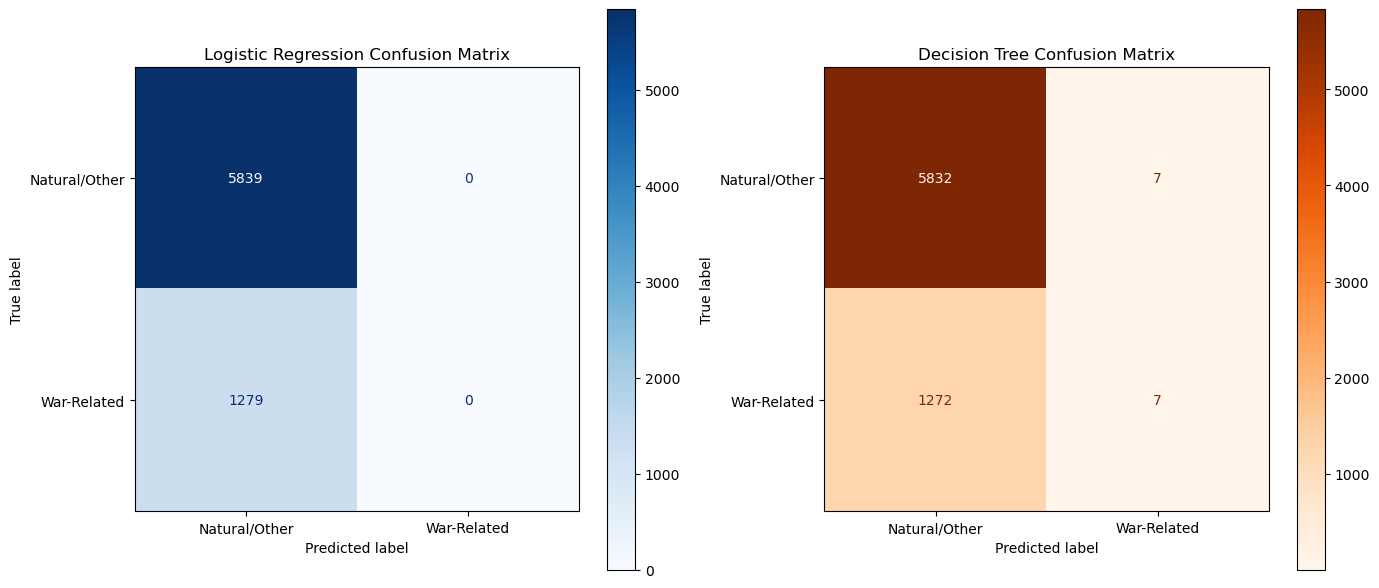

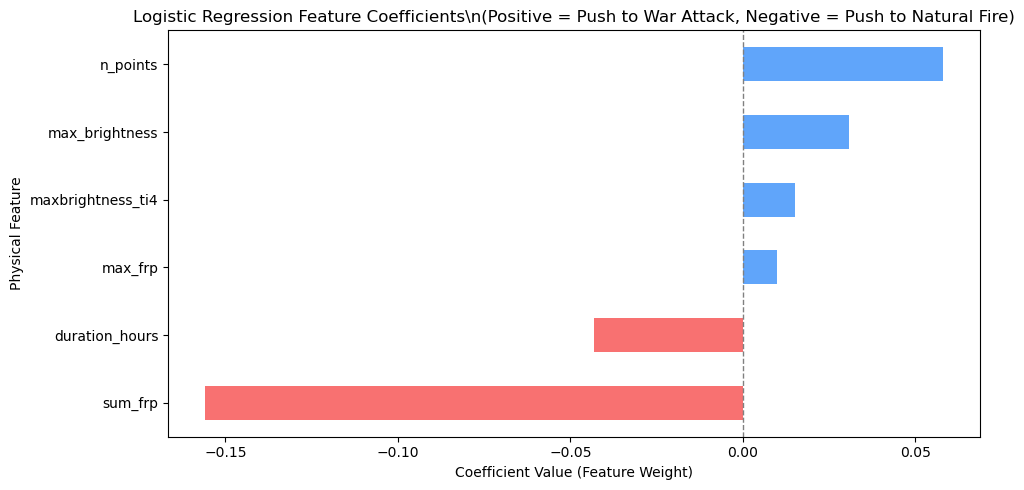

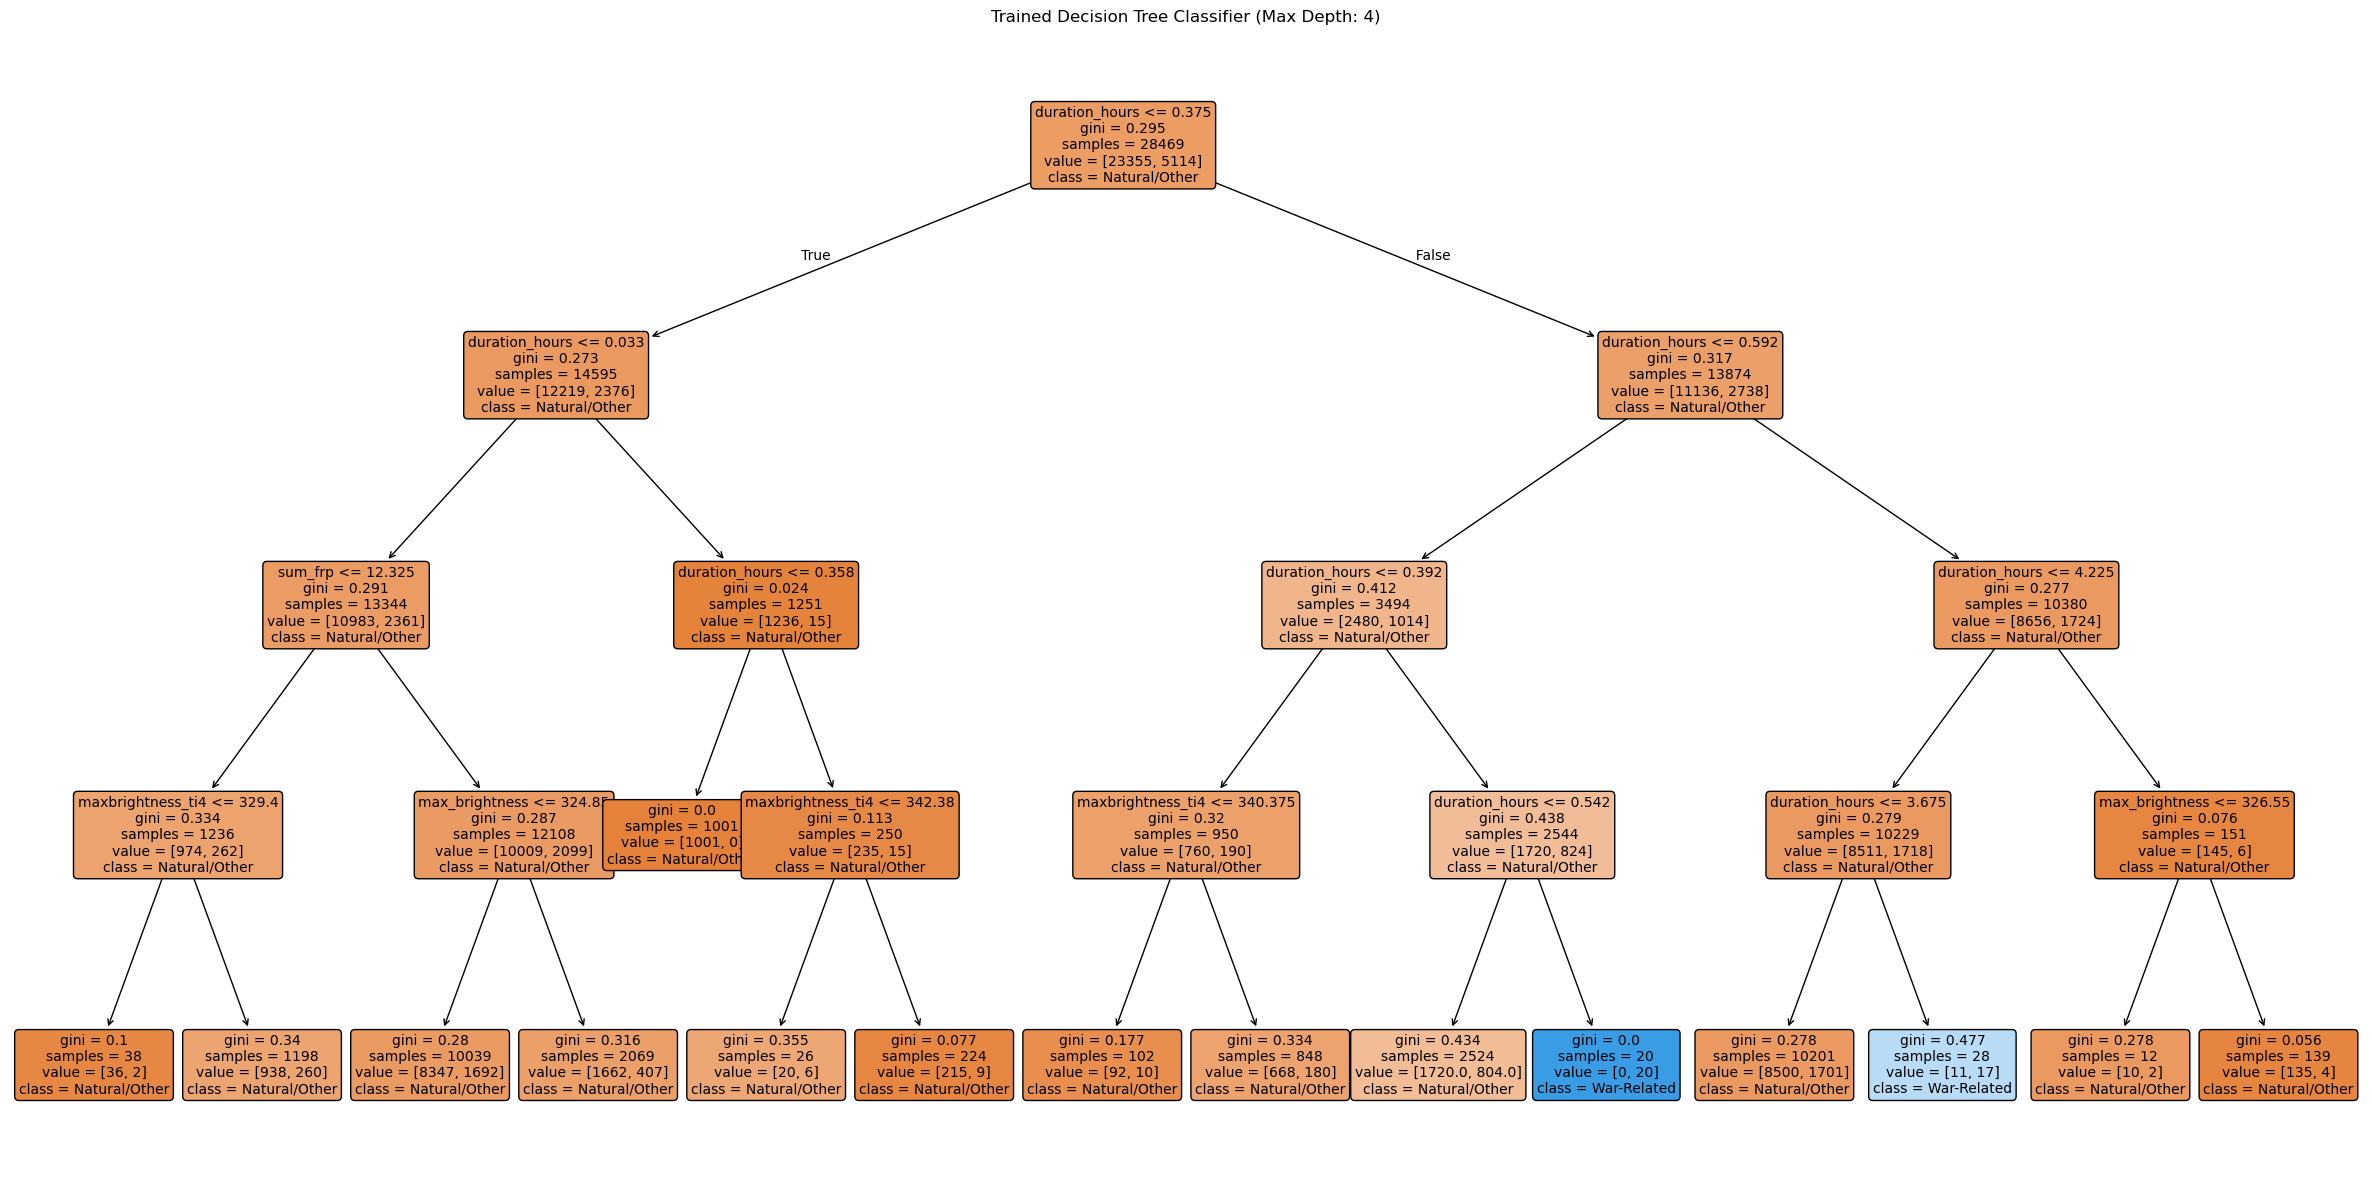

In [3]:
import pandas as pd
import numpy as np
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier, export_text, plot_tree
from sklearn.metrics import classification_report, accuracy_score, ConfusionMatrixDisplay
import matplotlib.pyplot as plt
ROOT = Path(r"c:\.Okul\CE49X Introduction to Computational Thinking and Data Science for Civil Engineers\GithubRepository\CE49X\Final Project")
FIRMS_PROCESSED = ROOT / "FIRMS" / "data" / "processed"
# Load both datasets
dfs = []
for csv_path in sorted(FIRMS_PROCESSED.glob("crrltd_*.csv")):
    df_temp = pd.read_csv(csv_path)
    if not df_temp.empty:
        dfs.append(df_temp)
if not dfs:
    raise FileNotFoundError("No crrltd_*.csv files were found.")
df = pd.concat(dfs, ignore_index=True)
# Select physical features (only satellite data, no news data!)
feature_cols = [
    "n_points",
    "max_brightness",
    "maxbrightness_ti4",
    "sum_frp",
    "max_frp",
    "duration_hours"
]
# Select features and fill NaNs with 0 (representing absence of that sensor's signal)
X = df[feature_cols].copy()
X["max_brightness"] = X["max_brightness"].fillna(0)
X["maxbrightness_ti4"] = X["maxbrightness_ti4"].fillna(0)
X["sum_frp"] = X["sum_frp"].fillna(0)
X["max_frp"] = X["max_frp"].fillna(0)
X["duration_hours"] = X["duration_hours"].fillna(0)
# Target label: y = 1 for high confidence war match, y = 0 otherwise
y = df["high_confidence_match"].astype(int)
# Train-Test Split (80% train, 20% test, stratified to maintain class balance)
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print(f"Total training samples: {len(X_train)} (Positive: {sum(y_train)}, Negative: {len(y_train) - sum(y_train)})")
print(f"Total testing samples: {len(X_test)} (Positive: {sum(y_test)}, Negative: {len(y_test) - sum(y_test)})")
print("-" * 60)
# --- 1. Logistic Regression Model ---
print("Training Logistic Regression Model...")
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)
lr_model = LogisticRegression(random_state=42, max_iter=1000)
lr_model.fit(X_train_scaled, y_train)
lr_preds = lr_model.predict(X_test_scaled)
print("\\n[Logistic Regression Performance]")
print(f"Accuracy: {accuracy_score(y_test, lr_preds):.4f}")
print(classification_report(y_test, lr_preds, target_names=["Natural/Other", "War-Related"]))
print("-" * 60)
# --- 2. Decision Tree Model ---
print("Training Decision Tree Model...")
# Capped at depth 4 to prevent overfitting and ensure high interpretability
dt_model = DecisionTreeClassifier(max_depth=4, random_state=42)
dt_model.fit(X_train, y_train)
dt_preds = dt_model.predict(X_test)
print("\\n[Decision Tree Performance]")
print(f"Accuracy: {dt_model.score(X_test, y_test):.4f}")
print(classification_report(y_test, dt_preds, target_names=["Natural/Other", "War-Related"]))
print("-" * 60)
# Print Feature Importances
print("Decision Tree Feature Importances:")
importances = dt_model.feature_importances_
for name, importance in sorted(zip(feature_cols, importances), key=lambda x: x[1], reverse=True):
    print(f"  {name:25}: {importance:.4f}")
print("-" * 60)
# Print Textual Decision Tree Rules
print("Learned Decision Rules (Decision Tree):")
tree_rules = export_text(dt_model, feature_names=feature_cols)
print(tree_rules)
print("-" * 60)
# --- 3. Visualizations ---
print("Generating model visualizations...")
# 3.1. Side-by-Side Confusion Matrices
fig, axes = plt.subplots(1, 2, figsize=(14, 6))
ConfusionMatrixDisplay.from_predictions(
    y_test, lr_preds, 
    display_labels=["Natural/Other", "War-Related"], 
    cmap="Blues", 
    ax=axes[0]
)
axes[0].set_title("Logistic Regression Confusion Matrix")
ConfusionMatrixDisplay.from_predictions(
    y_test, dt_preds, 
    display_labels=["Natural/Other", "War-Related"], 
    cmap="Oranges", 
    ax=axes[1]
)
axes[1].set_title("Decision Tree Confusion Matrix")
plt.tight_layout()
plt.show()
# 3.2. Logistic Regression Feature Coefficients
plt.figure(figsize=(10, 5))
coef_series = pd.Series(lr_model.coef_[0], index=feature_cols).sort_values()
colors = ["#f87171" if x < 0 else "#60a5fa" for x in coef_series.values]
coef_series.plot(kind="barh", color=colors)
plt.axvline(0, color="gray", linestyle="--", linewidth=1.0)
plt.title("Logistic Regression Feature Coefficients\\n(Positive = Push to War Attack, Negative = Push to Natural Fire)")
plt.xlabel("Coefficient Value (Feature Weight)")
plt.ylabel("Physical Feature")
plt.tight_layout()
plt.show()
# 3.3. Decision Tree Architecture Plot
plt.figure(figsize=(24, 12))
plot_tree(
    dt_model, 
    feature_names=feature_cols, 
    class_names=["Natural/Other", "War-Related"], 
    filled=True, 
    rounded=True, 
    fontsize=10
)
plt.title("Trained Decision Tree Classifier (Max Depth: 4)")
plt.tight_layout()
plt.show()